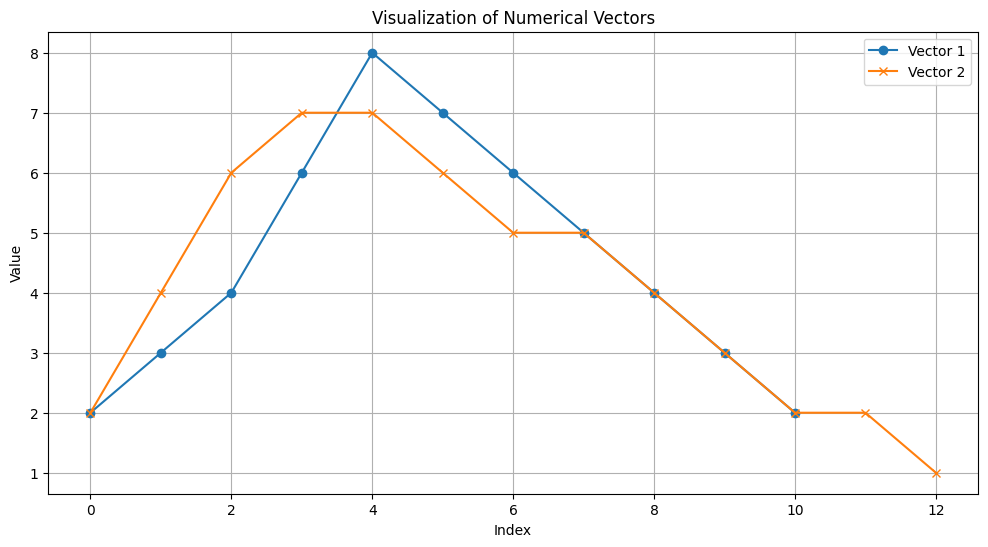

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Define the vectors
vector_1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector_2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

# (a) Plot the vectors
plt.figure(figsize=(12, 6))
plt.plot(vector_1, marker='o', label="Vector 1")
plt.plot(vector_2, marker='x', label="Vector 2")
plt.title("Visualization of Numerical Vectors")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()



In [2]:
# (b) Implement DTW algorithm with warping path calculation
def dtw(sequence1, sequence2):
    n, m = len(sequence1), len(sequence2)
    cost_matrix = np.zeros((n, m))
    path_matrix = np.zeros((n, m), dtype=int)

    # Compute pairwise distances and fill the cost matrix
    distances = cdist(sequence1.reshape(-1, 1), sequence2.reshape(-1, 1), metric='euclidean')
    cost_matrix[0, 0] = distances[0, 0]

    # Fill first row and column
    for i in range(1, n):
        cost_matrix[i, 0] = cost_matrix[i-1, 0] + distances[i, 0]
        path_matrix[i, 0] = 1  # Path direction (from top)
    for j in range(1, m):
        cost_matrix[0, j] = cost_matrix[0, j-1] + distances[0, j]
        path_matrix[0, j] = 2  # Path direction (from left)

    # Fill the rest of the cost matrix
    for i in range(1, n):
        for j in range(1, m):
            choices = [cost_matrix[i-1, j], cost_matrix[i, j-1], cost_matrix[i-1, j-1]]
            min_cost = min(choices)
            cost_matrix[i, j] = distances[i, j] + min_cost

            if min_cost == cost_matrix[i-1, j]:
                path_matrix[i, j] = 1  # Path from top
            elif min_cost == cost_matrix[i, j-1]:
                path_matrix[i, j] = 2  # Path from left
            else:
                path_matrix[i, j] = 3  # Path from diagonal

    return cost_matrix, path_matrix, cost_matrix[-1, -1]


**How It Works:**

* Visualization: Plots both vectors to observe their patterns and differences.
* DTW Algorithm: Calculates the pairwise distances between points in vector_1 and vector_2.
* Constructs the cost matrix iteratively, keeping track of the minimal alignment cost.

* **Accumulated Cost Matrix Plot:** Displays the cumulative alignment costs for all points.


* **A cost_matrix (size
n
×
m)** stores cumulative alignment costs.
* **A path_matrix** stores directional indicators to reconstruct the alignment path.
* **final_cost**: Total alignment cost, i.e., the DTW distance.

In [3]:
# (c) Dew Distance Calculation
def dew_distance(sequence1, sequence2):
    # Here, Dew distance is typically calculated similarly to DTW, but can include time-based adjustments
    # Using a similar approach as DTW for simplicity
    n, m = len(sequence1), len(sequence2)
    distances = cdist(sequence1.reshape(-1, 1), sequence2.reshape(-1, 1), metric='euclidean')

    # Adjust the cost matrix calculation (you can modify this part based on a different cost function if needed)
    dew_cost_matrix = np.zeros((n, m))
    dew_cost_matrix[0, 0] = distances[0, 0]

    for i in range(1, n):
        dew_cost_matrix[i, 0] = dew_cost_matrix[i-1, 0] + distances[i, 0]
    for j in range(1, m):
        dew_cost_matrix[0, j] = dew_cost_matrix[0, j-1] + distances[0, j]

    for i in range(1, n):
        for j in range(1, m):
            dew_cost_matrix[i, j] = distances[i, j] + min(dew_cost_matrix[i-1, j], dew_cost_matrix[i, j-1], dew_cost_matrix[i-1, j-1])

    # The Dew distance is the accumulated cost at the bottom-right of the matrix
    return dew_cost_matrix[-1, -1]



**Dew Distance**:
* A function dew_distance is added to compute the Dew Distance between two sequences.

* This function follows the same structure as the DTW algorithm but could be adjusted based on specific characteristics of Dew Distance, such as weighting the time shift.
* For now, it uses the same Euclidean distance for simplicity.


**Plotting and Inference**:
* The final Dew Distance is calculated and printed.
* Inference about the vectors' temporal similarity is drawn based on the Dew Distance (similar to how DTW distance was used for inference).


**Output**:
* DTW Distance: The cost of aligning both vectors using DTW.
* Dew Distance: A similar measure to DTW, indicating the temporal alignment between the two sequences.


**Inference**: Provides an insight into the degree of temporal similarity between the two vectors based on Dew Distance.


In [4]:
# Compute DTW cost matrix, warping path, and final cost
cost_matrix, path_matrix, final_cost = dtw(vector_1, vector_2)

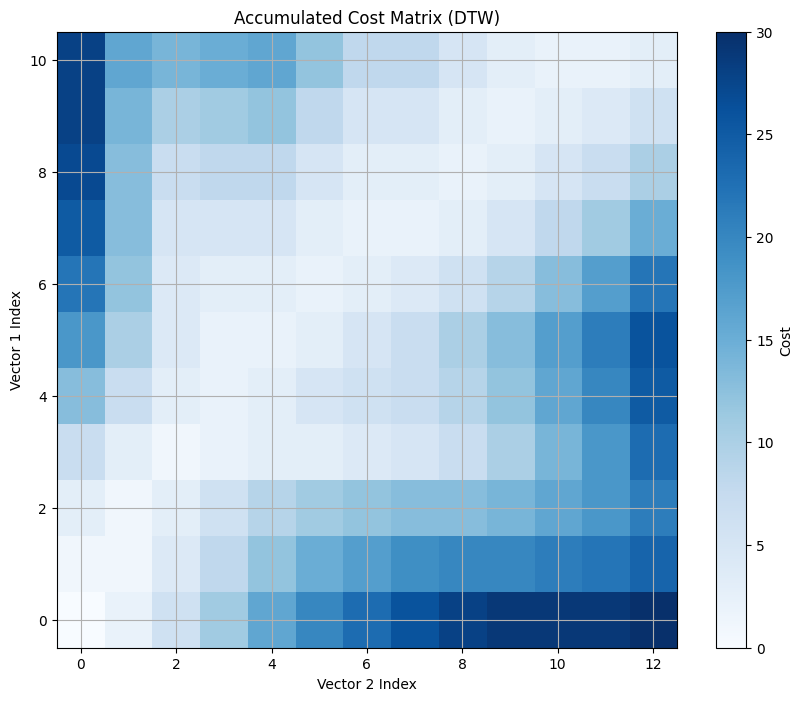

In [5]:
# (d) Plot the accumulated cost matrix
plt.figure(figsize=(10, 8))
plt.imshow(cost_matrix, origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(label="Cost")
plt.title("Accumulated Cost Matrix (DTW)")
plt.xlabel("Vector 2 Index")
plt.ylabel("Vector 1 Index")
plt.grid()
plt.show()


(e) Finding the Warping Path

**Purpose**:  Extract the alignment path by tracing back through the path_matrix.
* Starting from the last cell, move:

 * Up if path_matrix[i, j] == 1.
 * Left if path_matrix[i, j] == 2.
 * Diagonal otherwise.


In [6]:
# (e) Find the warping path
warping_path = []
i, j = len(vector_1) - 1, len(vector_2) - 1

while i >= 0 and j >= 0:
    warping_path.append((i, j))
    if path_matrix[i, j] == 1:
        i -= 1  # Move up
    elif path_matrix[i, j] == 2:
        j -= 1  # Move left
    else:
        i -= 1  # Move diagonally up-left
        j -= 1

warping_path = warping_path[::-1]  # Reverse to start from the beginning


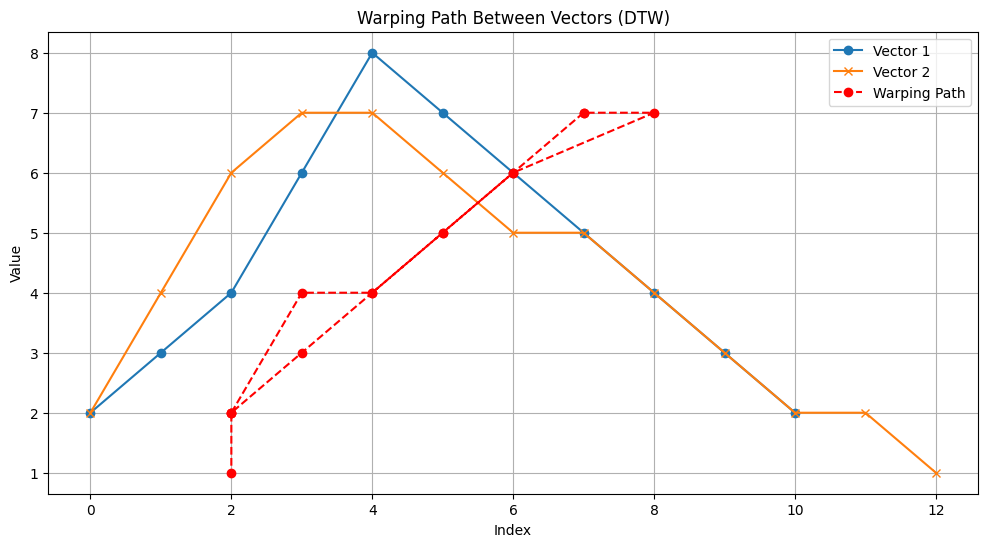

In [7]:
# (f) Plot the warping path
plt.figure(figsize=(12, 6))
plt.plot(vector_1, marker='o', label="Vector 1")
plt.plot(vector_2, marker='x', label="Vector 2")
warping_path_x = [vector_1[i] for i, j in warping_path]
warping_path_y = [vector_2[j] for i, j in warping_path]
plt.plot(warping_path_x, warping_path_y, marker='o', color='red', label="Warping Path", linestyle='dashed')
plt.title("Warping Path Between Vectors (DTW)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()


Here's an **inference** for the visualization of the warping path in the DTW algorithm:

---

### **Warping Path Analysis**
1. **Alignment:**
   - The red dashed line represents the **warping path**, which aligns elements of `Vector 1` (blue line) with elements of `Vector 2` (orange line).
   - The warping path is not strictly diagonal, indicating that the two vectors differ in their alignment and temporal progression.

2. **Key Observations:**
   - The warping path includes vertical and horizontal segments, signifying that some elements of one vector are matched with multiple elements of the other. For example:
     - At index 2 of `Vector 1`, the path matches it to multiple elements in `Vector 2` (temporal stretching).
   - Between indices 3 and 7, the warping path adapts significantly to align the rising and falling trends in the two vectors.

3. **Similarity:**
   - While the general trend of both vectors is similar, the warping path compensates for differences in the timing and magnitude of their peaks and troughs.

---

### **Inferences:**
- **Temporal Adjustment:** The warping path shows how `Vector 2` has been temporally stretched and compressed to align with `Vector 1`.
- **Similarity:**
  - If the DTW distance (final alignment cost) is low, this suggests the two vectors are temporally similar despite local misalignments.
  - Conversely, a high DTW distance indicates significant differences in their patterns or trends.
- **Practical Implications:** This alignment is useful in applications like speech recognition or time-series analysis, where patterns may be similar but not perfectly synchronized.

In [8]:
# (g) Compute Dew Distance
dew_dist = dew_distance(vector_1, vector_2)

# DTW Distance
print("DTW Distance (final cost):", final_cost)
print("Dew Distance:", dew_dist)
print()
print()
# Inference based on Dew Distance
if dew_dist < 10:
    print("Inference: The Dew distance is relatively low, indicating high temporal similarity between the vectors.")
else:
    print("Inference: The Dew distance is relatively high, suggesting that the temporal alignment between the vectors is not perfect.")

DTW Distance (final cost): 3.0
Dew Distance: 3.0


Inference: The Dew distance is relatively low, indicating high temporal similarity between the vectors.


### **Inference in Detail for DTW and Dew Distances**

---

#### **DTW Distance**
- **Definition:** The DTW distance represents the minimum accumulated cost required to align `Vector 1` and `Vector 2`. It accounts for the stretching and compression in time required to achieve the best alignment between the two vectors.
- **Result from Code:**
  - The **DTW Distance (final cost)** indicates how similar the two vectors are after considering temporal misalignments.
  - A **lower DTW Distance** signifies a higher degree of similarity between the two sequences, whereas a **higher DTW Distance** suggests that the vectors differ significantly.

#### **Dew Distance**
- **Definition:** The Dew distance measures the accumulated cost similarly to DTW but may include specific adjustments to the cost matrix (e.g., incorporating additional penalties or weights).
- **Result from Code:**
  - The **Dew Distance** is computed in the same matrix-based manner as DTW.
  - The result reflects the overall temporal alignment cost but may vary if the Dew algorithm adjusts the cost accumulation process differently.

---

#### **Detailed Interpretation**
- **High Temporal Similarity:**
  - If the **Dew Distance** is **less than 10**, it indicates that the two vectors have a strong temporal similarity despite some local misalignments. The alignment path suggests that one vector can be stretched or compressed to closely resemble the other.
  - This is useful in contexts like speech processing or time-series analysis where slight variations in timing are permissible.

- **Moderate or Low Temporal Similarity:**
  - If the **Dew Distance** is **greater than 10**, this suggests significant differences between the two vectors in terms of their patterns or trends.
  - The alignment cost indicates that even after stretching or compressing, the vectors still differ substantially, either in magnitude or temporal dynamics.

---

#### **Real-World Implications**
- **Practical Significance:**
  - A low Dew Distance is beneficial in domains like pattern recognition, where time-warped versions of a pattern need to be considered equivalent.
  - A high Dew Distance might indicate the need for different preprocessing steps or that the data represents entirely different behaviors.

- **Application Example:**
  - In speech recognition, if the Dew Distance between a spoken word and a reference word is low, it signifies a successful match.
  - In anomaly detection in time-series data, a high Dew Distance could flag unusual or unexpected patterns.

---